# Assignment 3 — Machine Learning
## Applying Machine Learning to the 2026 F1 Qualifying Dataset

**Dataset:** 2026 Australian Grand Prix — Qualifying session telemetry

In Assignment 2 I did a full exploratory analysis of the qualifying data and found that average lap speed (`speed_mean`) is the variable that best separates the qualifying groups, with ε² = 0.83 on the Kruskal-Wallis test.

For this assignment the idea is to use Machine Learning to see if an algorithm can reach the same conclusion on its own, without me guiding the analysis.

I'm going to do this in two ways:

1. **Clustering (K-Means)** — let the algorithm group drivers based only on telemetry, without knowing anything about who made it to Q3 or not
2. **Classification (Random Forest)** — train a model to predict whether a driver reached Q3, and check which features it considered most important


## 1. Importing the libraries

Here I import everything I'll need: pandas and numpy for data manipulation, scikit-learn for the ML algorithms, and matplotlib/plotly for the charts.


In [49]:
# Core data manipulation
import json
import numpy as np
import pandas as pd

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score
)

# Visualization
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "iframe"

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")


Libraries loaded successfully


## 2. Extracting telemetry features

The telemetry data is stored as a JSON field inside each row of the CSV — it contains speed, throttle, brake and gear sampled every 0.5 seconds along the lap.

For each driver I took their best qualifying lap and calculated 5 summary metrics:

| Feature | What it represents |
|---|---|
| `speed_mean` | Average lap speed (km/h) |
| `speed_min` | Minimum speed — performance through the slowest corners |
| `speed_std` | Speed standard deviation — variation between corners and straights |
| `throttle_pct` | % of the lap with throttle > 50% |
| `brake_pct` | % of the lap with any braking |

These were the metrics that showed the most discriminating power in Assignment 2.


In [50]:
DATA_PATH = "/Users/ftomelin/Documents/Repos/DataScienceFurb/data/raw/All Laps Update 13032026.csv"

# Load and filter to qualifying session — Australian GP
df_all = pd.read_csv(DATA_PATH)
df_q = df_all[
    (df_all["session_type"] == "Q") &
    (df_all["event_name"]   == "Australian Grand Prix")
].copy().reset_index(drop=True)

# Personal best lap per driver, ranked by lap time
best_q = (
    df_q.sort_values("lap_duration")
      .groupby("driver", sort=False)
      .first()
      .reset_index()
      .sort_values("lap_duration")
      .reset_index(drop=True)
)
best_q["rank"]  = range(1, len(best_q) + 1)
best_q["group"] = best_q["rank"].apply(
    lambda r: "Q3" if r <= 10 else ("Q2" if r <= 15 else "Q1")
)

def extract_features(row):
    """Parse telemetry JSON and return aggregated driving-style metrics."""
    raw = row.get("telemetry")
    if pd.isna(raw):
        return None
    try:
        frames = json.loads(raw)
    except Exception:
        return None
    if not frames:
        return None
    spd = [f["speed"]    for f in frames if f.get("speed")    is not None]
    thr = [f["throttle"] for f in frames if f.get("throttle") is not None]
    brk = [f["brake"]    for f in frames if f.get("brake")    is not None]
    if not spd:
        return None
    spd_arr = np.array(spd)
    return {
        "speed_mean":    float(spd_arr.mean()),
        "speed_min":     float(spd_arr.min()),
        "speed_std":     float(spd_arr.std()),
        "throttle_pct":  float(np.mean([1 if t > 50 else 0 for t in thr]) * 100) if thr else None,
        "brake_pct":     float(np.mean([1 if b > 0  else 0 for b in brk]) * 100) if brk else None,
    }

rows = []
for _, row in best_q.iterrows():
    feats = extract_features(row)
    if feats is None:
        continue
    rows.append({"driver": row["driver"], "group": row["group"],
                 "rank": row["rank"], "lap_duration": row["lap_duration"], **feats})

tdf = pd.DataFrame(rows)
FEATURES = ["speed_mean", "speed_min", "speed_std", "throttle_pct", "brake_pct"]

print(f"Drivers with telemetry: {len(tdf)}  |  Groups: {tdf['group'].value_counts().to_dict()}")


Drivers with telemetry: 20  |  Groups: {'Q3': 10, 'Q2': 5, 'Q1': 5}


In [51]:
# Feature matrix overview — note VER (rank 20, 102 s) as clear outlier
display(
    tdf[["rank", "driver", "group", "lap_duration"] + FEATURES]
    .round({"lap_duration": 2, "speed_mean": 1, "speed_min": 0,
            "speed_std": 1, "throttle_pct": 1, "brake_pct": 1})
    .reset_index(drop=True)
)

,rank,driver,group,lap_duration,speed_mean,speed_min,speed_std,throttle_pct,brake_pct
0,1,RUS,Q3,78.52,240.0,94.0,62.5,75.3,12.7
1,2,ANT,Q3,78.81,239.8,98.0,60.4,75.9,12.7
2,3,HAD,Q3,79.30,237.8,93.0,62.6,74.2,10.1
3,4,LEC,Q3,79.33,237.8,102.0,59.3,76.7,10.7
4,5,PIA,Q3,79.38,237.5,95.0,61.2,73.0,10.7
5,6,NOR,Q3,79.47,236.9,95.0,60.7,71.1,10.7
6,7,HAM,Q3,79.48,237.8,99.0,58.7,78.0,10.1
7,8,LIN,Q3,79.97,235.4,96.0,63.7,80.0,10.6
8,9,LAW,Q3,79.99,235.3,90.0,65.0,78.1,13.8
9,10,BOR,Q3,80.22,235.2,95.0,62.2,80.7,12.4


## 3. Unsupervised Learning: K-Means Clustering

### 3.1 Idea

The question here is: can an algorithm, looking only at telemetry and without knowing any qualifying results, group the drivers in a way that makes sense?

Before running K-Means I had to do two things:

1. **Standardize the features** — each variable has a different scale. Without scaling, `speed_mean` (values around 230) would completely dominate `brake_pct` (values around 12)
2. **PCA to 2 dimensions** — just to be able to visualize the clusters in a 2D plot. The algorithm itself runs on all 5 features


In [52]:
# Standardize: zero mean, unit variance
X = tdf[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
tdf["pc1"] = X_pca[:, 0]
tdf["pc2"] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]*100:.1f}% of variance")
print(f"PC2 explains {explained[1]*100:.1f}% of variance")
print(f"Total explained by 2 PCs: {sum(explained)*100:.1f}%")

# PCA loadings — which features drive each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=["PC1", "PC2"]
).round(3)
print("\nPCA loadings (contribution of each feature to each PC):")
display(loadings)


PC1 explains 76.2% of variance
PC2 explains 14.2% of variance
Total explained by 2 PCs: 90.4%

PCA loadings (contribution of each feature to each PC):


,PC1,PC2
speed_mean,0.484,0.209
speed_min,0.491,0.238
speed_std,-0.461,0.146
throttle_pct,0.450,0.314
brake_pct,-0.331,0.883


### 3.2 Choosing the number of clusters k

To decide the value of k I ran K-Means from k=2 to k=6 and evaluated two criteria:

- **Inertia (Elbow)**: sum of distances within each cluster — lower is better. I'm looking for the "elbow" where the drop slows down
- **Silhouette score**: measures how well-separated the clusters are. Ranges from -1 to 1, higher is better


k=2  inertia=31.2  silhouette=0.757
k=3  inertia=20.5  silhouette=0.236
k=4  inertia=15.4  silhouette=0.227
k=5  inertia=11.9  silhouette=0.202
k=6  inertia=9.5  silhouette=0.226


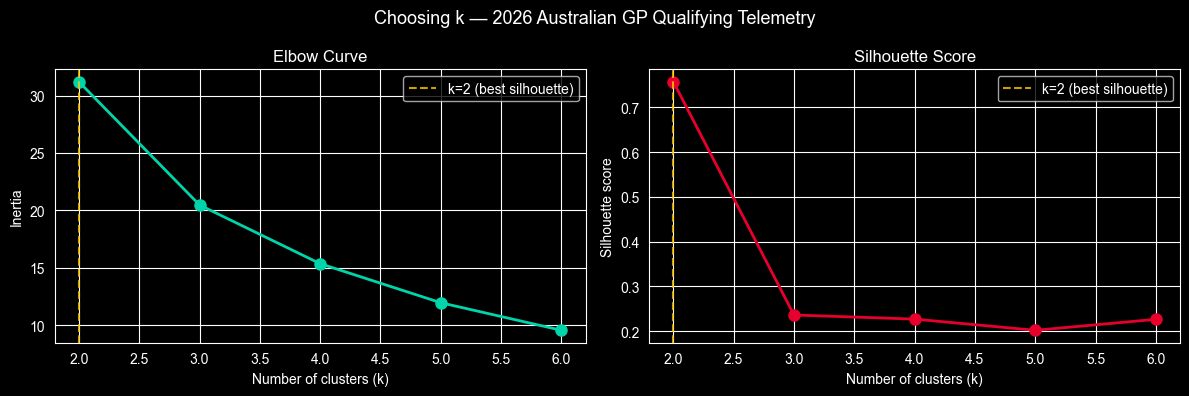

In [53]:
inertia_vals, silhouette_vals = [], []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_vals.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_vals.append(sil)
    print(f"k={k}  inertia={km.inertia_:.1f}  silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertia_vals, "o-", color="#00D4AA", linewidth=2, markersize=8)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Curve")
axes[0].axvline(x=2, linestyle="--", color="#FFC906", alpha=0.8, label="k=2 (best silhouette)")
axes[0].legend()

axes[1].plot(list(k_range), silhouette_vals, "o-", color="#E8002D", linewidth=2, markersize=8)
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score")
axes[1].axvline(x=2, linestyle="--", color="#FFC906", alpha=0.8, label="k=2 (best silhouette)")
axes[1].legend()

plt.suptitle("Choosing k — 2026 Australian GP Qualifying Telemetry", fontsize=13)
plt.tight_layout()
plt.show()


### 3.3 The VER problem

Before interpreting the results I need to talk about **VER** (Verstappen): he ran a 102-second lap because it was an out-lap that was aborted due to a mechanical issue. His average speed was 190 km/h with a minimum of 42 km/h — completely outside the range of the other drivers who stayed between 78-83 s and 224-240 km/h average.

What happens when I run K-Means with k=3 including VER: the algorithm uses an entire cluster just to isolate him, and only 2 clusters are left for the other 19 drivers. This doesn't reveal anything about the Q3/Q2/Q1 structure.

So I decided to test **two approaches**:
- **k=2 with all 20 drivers**: just separates VER from the rest
- **k=3 without VER**: removes the outlier and looks for 3 groups among the 19 competitive drivers


In [54]:
# ── Strategy 1: k=2, all 20 drivers ──────────────────────────────────────
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
tdf["cluster_k2"] = km2.fit_predict(X_scaled)

# Label clusters by speed_mean (fastest = "Competitive", slowest = "Outlier")
c2_speed = tdf.groupby("cluster_k2")["speed_mean"].mean().sort_values(ascending=False)
map2 = {old: new for new, old in enumerate(c2_speed.index)}
cluster2_names = {0: "Competitive", 1: "Outlier"}
tdf["cluster_k2_name"] = tdf["cluster_k2"].map(map2).map(cluster2_names)

sil_k2_all = silhouette_score(X_scaled, tdf["cluster_k2"])
print(f"k=2 (all drivers) — Silhouette: {sil_k2_all:.3f}")
print(tdf[["driver","group","cluster_k2_name","speed_mean","lap_duration"]].to_string(index=False))


k=2 (all drivers) — Silhouette: 0.757
driver group cluster_k2_name  speed_mean  lap_duration
   RUS    Q3     Competitive  240.018987        78.518
   ANT    Q3     Competitive  239.791139        78.811
   HAD    Q3     Competitive  237.792453        79.303
   LEC    Q3     Competitive  237.823899        79.327
   PIA    Q3     Competitive  237.465409        79.380
   NOR    Q3     Competitive  236.886792        79.475
   HAM    Q3     Competitive  237.754717        79.478
   LIN    Q3     Competitive  235.418750        79.971
   LAW    Q3     Competitive  235.300000        79.994
   BOR    Q3     Competitive  235.192547        80.221
   HUL    Q2     Competitive  234.956522        80.303
   BEA    Q2     Competitive  234.354037        80.311
   OCO    Q2     Competitive  233.409938        80.491
   GAS    Q2     Competitive  234.888889        80.501
   ALB    Q2     Competitive  232.839506        80.941
   COL    Q1     Competitive  232.190184        81.200
   ALO    Q1     Competitiv

In [55]:
# ── Strategy 2: k=3, VER excluded ────────────────────────────────────────
tdf_no_ver = tdf[tdf["driver"] != "VER"].copy().reset_index(drop=True)
X_no_ver = tdf_no_ver[FEATURES].values
scaler2  = StandardScaler()
X_no_ver_scaled = scaler2.fit_transform(X_no_ver)

pca2 = PCA(n_components=2, random_state=42)
X_no_ver_pca = pca2.fit_transform(X_no_ver_scaled)
tdf_no_ver["pc1"] = X_no_ver_pca[:, 0]
tdf_no_ver["pc2"] = X_no_ver_pca[:, 1]

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
tdf_no_ver["cluster_k3"] = km3.fit_predict(X_no_ver_scaled)

# Label by speed_mean
c3_speed = tdf_no_ver.groupby("cluster_k3")["speed_mean"].mean().sort_values(ascending=False)
map3 = {old: new for new, old in enumerate(c3_speed.index)}
cluster3_names = {0: "Fast", 1: "Mid", 2: "Slow"}
tdf_no_ver["cluster_k3_name"] = tdf_no_ver["cluster_k3"].map(map3).map(cluster3_names)

sil_k3 = silhouette_score(X_no_ver_scaled, tdf_no_ver["cluster_k3"])
ari_k3  = adjusted_rand_score(tdf_no_ver["group"], tdf_no_ver["cluster_k3_name"])
nmi_k3  = normalized_mutual_info_score(tdf_no_ver["group"], tdf_no_ver["cluster_k3_name"])

print(f"k=3 (VER excluded) — Silhouette: {sil_k3:.3f} | ARI: {ari_k3:.3f} | NMI: {nmi_k3:.3f}")
print()
print(pd.crosstab(tdf_no_ver["cluster_k3_name"], tdf_no_ver["group"],
                  margins=True, margins_name="Total").to_string())


k=3 (VER excluded) — Silhouette: 0.215 | ARI: 0.370 | NMI: 0.566

group            Q1  Q2  Q3  Total
cluster_k3_name                   
Fast              0   0   6      6
Mid               0   4   4      8
Slow              4   1   0      5
Total             4   5  10     19


In [56]:
# ── Visualization: k=3 clustering in PCA space (VER excluded) ───────────
explained2 = pca2.explained_variance_ratio_

CLUSTER_COLORS = {"Fast": "#00D4AA", "Mid": "#FFC906", "Slow": "#E8002D"}
GROUP_SYMBOLS  = {"Q3": "circle", "Q2": "square", "Q1": "diamond"}

fig = go.Figure()

for cname, ccolor in CLUSTER_COLORS.items():
    sub = tdf_no_ver[tdf_no_ver["cluster_k3_name"] == cname]
    for gname, gsym in GROUP_SYMBOLS.items():
        pts = sub[sub["group"] == gname]
        if len(pts) == 0:
            continue
        fig.add_trace(go.Scatter(
            x=pts["pc1"], y=pts["pc2"],
            mode="markers+text",
            marker=dict(size=14, color=ccolor, symbol=gsym,
                        line=dict(width=1.5, color="white")),
            text=pts["driver"],
            textposition="top center",
            textfont=dict(size=10),
            name=f"{cname} cluster / {gname}",
            hovertemplate=(
                "<b>%{text}</b><br>Cluster: " + cname +
                "<br>PC1: %{x:.2f} | PC2: %{y:.2f}<extra></extra>"
            )
        ))

fig.update_layout(
    title=dict(
        text=(
            f"K-Means (k=3) in PCA Space — 2026 Australian GP Qualifying (VER excluded)<br>"
            f"<sup>Color = cluster | Shape = qualifying group (● Q3 ■ Q2 ◆ Q1) | "
            f"PC1+PC2 = {sum(explained2)*100:.1f}% of variance</sup>"
        ),
        font=dict(size=14)
    ),
    xaxis_title=f"PC1 ({explained2[0]*100:.1f}% variance — speed-dominant axis)",
    yaxis_title=f"PC2 ({explained2[1]*100:.1f}% variance)",
    legend_title="Cluster / Group",
    width=900, height=550,
    template="plotly_white"
)
fig.show()


### 3.4 Clustering interpretation

**k=2 (with VER):** The high silhouette happens because VER is so far from everyone else. The algorithm separates him from the rest easily, but that's not an interesting finding — it's just the outlier being detected.

**k=3 (without VER):** This is more interesting. An ARI of 0.37 and NMI of 0.57 mean the clusters have some correspondence with the actual qualifying groups, but it's not perfect.

What the algorithm found was a "Fast" cluster with the top Q3 drivers (highest `speed_mean` and `speed_min`), a "Slow" cluster capturing the Q1 dropouts, and a middle cluster where Q2 and part of Q3 mix together.

This makes sense: the biggest telemetry difference is between Q3 and Q1. The Q2/Q3 boundary is very close — and the algorithm reflected exactly that, which is consistent with what I showed in Assignment 2.


## 4. Supervised Learning: Binary Classification (Q3 vs non-Q3)

### 4.1 Problem setup

Here I switched to a supervised approach. The goal is to predict whether a driver made it to Q3 or not, using only telemetry features.

| Label | Meaning |
|---|---|
| **1 (Q3)** | Driver advanced to Q3 (top 10) |
| **0 (non-Q3)** | Driver was eliminated in Q1 or Q2 |

**Why binary?** The clustering showed that the Q2/Q1 boundary isn't well separable in telemetry. The Q3/non-Q3 boundary is clearer and is the most meaningful cutoff in qualifying.

VER stays excluded — an aborted lap doesn't represent qualifying performance.

**Algorithm:** Random Forest — works well with small datasets and naturally gives feature importance.

**Validation:** Since I only have 19 samples, I used Leave-One-Out Cross Validation (LOOCV). In each iteration I train on 18 drivers and test on the one left out, repeating for all 19. It's the most honest way to estimate accuracy with such a small dataset.


In [57]:
# Prepare features and binary label (Q3 = 1, non-Q3 = 0), exclude VER
tdf_ml = tdf[tdf["driver"] != "VER"].copy().reset_index(drop=True)

X_ml = tdf_ml[FEATURES].values
y_ml = (tdf_ml["group"] == "Q3").astype(int).values

# Scale (consistent with clustering pipeline)
scaler_ml = StandardScaler()
X_ml_scaled = scaler_ml.fit_transform(X_ml)

print(f"Samples: {len(tdf_ml)}  |  Q3=1: {y_ml.sum()}  |  non-Q3=0: {(1-y_ml).sum()}")
print(f"Class balance: {y_ml.mean()*100:.1f}% Q3")


Samples: 19  |  Q3=1: 10  |  non-Q3=0: 9
Class balance: 52.6% Q3


In [58]:
# ── Leave-One-Out Cross Validation ───────────────────────────────────────
loo = LeaveOneOut()
rf  = RandomForestClassifier(n_estimators=200, random_state=42, max_features="sqrt")

y_pred_loo  = np.zeros(len(y_ml), dtype=int)
y_proba_loo = np.zeros(len(y_ml))

for train_idx, test_idx in loo.split(X_ml_scaled):
    X_tr, X_te = X_ml_scaled[train_idx], X_ml_scaled[test_idx]
    y_tr        = y_ml[train_idx]
    rf.fit(X_tr, y_tr)
    y_pred_loo[test_idx]  = rf.predict(X_te)
    y_proba_loo[test_idx] = rf.predict_proba(X_te)[0, 1]

# Store predictions in tdf_ml for later use
tdf_ml["pred_label"]    = y_pred_loo
tdf_ml["pred_proba_Q3"] = y_proba_loo
tdf_ml["true_Q3"]       = y_ml
tdf_ml["correct"]       = (y_ml == y_pred_loo)

accuracy = accuracy_score(y_ml, y_pred_loo)
print(f"LOOCV Accuracy: {accuracy:.1%}  ({int(accuracy * len(y_ml))}/{len(y_ml)} correct)")
print()
print(classification_report(y_ml, y_pred_loo, target_names=["non-Q3", "Q3"]))


LOOCV Accuracy: 100.0%  (19/19 correct)

              precision    recall  f1-score   support

      non-Q3       1.00      1.00      1.00         9
          Q3       1.00      1.00      1.00        10

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



In [59]:
# ── Per-driver prediction table ───────────────────────────────────────────
pred_df = tdf_ml[["driver", "group", "lap_duration", "speed_mean",
                   "pred_label", "pred_proba_Q3"]].copy()
pred_df["true_Q3"] = y_ml
pred_df["correct"] = pred_df["true_Q3"] == pred_df["pred_label"]
pred_df["Predicted"] = pred_df["pred_label"].map({1: "Q3", 0: "non-Q3"})
pred_df["P(Q3)"] = pred_df["pred_proba_Q3"].round(3)
pred_df["✓"] = pred_df["correct"].map({True: "✓", False: "✗"})

display(
    pred_df[["driver","group","lap_duration","speed_mean","Predicted","P(Q3)","✓"]]
    .sort_values("lap_duration")
    .round({"lap_duration": 2, "speed_mean": 1})
    .reset_index(drop=True)
)

,driver,group,lap_duration,speed_mean,Predicted,P(Q3),✓
0,RUS,Q3,78.52,240.0,Q3,0.825,✓
1,ANT,Q3,78.81,239.8,Q3,0.830,✓
2,HAD,Q3,79.30,237.8,Q3,0.855,✓
3,LEC,Q3,79.33,237.8,Q3,0.970,✓
4,PIA,Q3,79.38,237.5,Q3,0.935,✓
5,NOR,Q3,79.47,236.9,Q3,0.950,✓
6,HAM,Q3,79.48,237.8,Q3,0.925,✓
7,LIN,Q3,79.97,235.4,Q3,0.780,✓
8,LAW,Q3,79.99,235.3,Q3,0.590,✓
9,BOR,Q3,80.22,235.2,Q3,0.595,✓


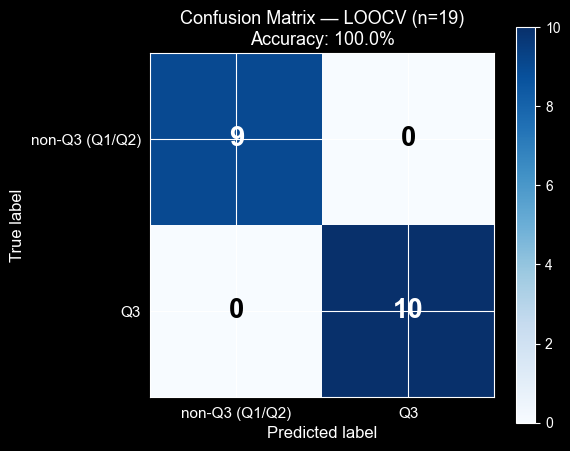

In [60]:
# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_ml, y_pred_loo)
labels = ["non-Q3 (Q1/Q2)", "Q3"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)
ax.set_title(f"Confusion Matrix — LOOCV (n=19)\nAccuracy: {accuracy:.1%}", fontsize=13)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center", fontsize=20, fontweight="bold",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()


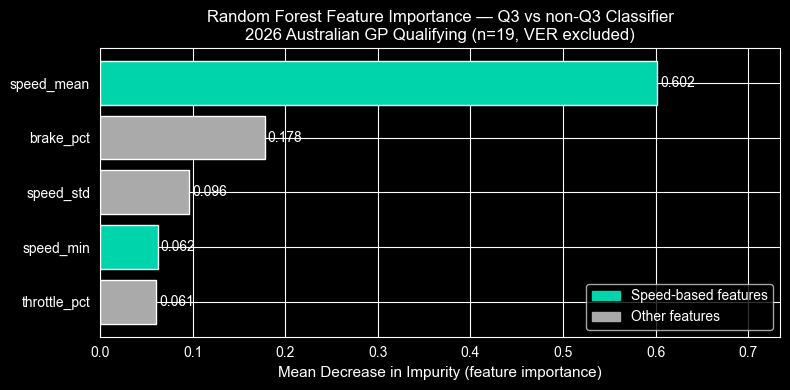

In [61]:
# ── Feature importance (model trained on full dataset) ────────────────────
rf_full = RandomForestClassifier(n_estimators=500, random_state=42, max_features="sqrt")
rf_full.fit(X_ml_scaled, y_ml)

importances = pd.Series(rf_full.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#00D4AA" if f in ["speed_mean", "speed_min"] else "#AAAAAA" for f in importances.index]
bars = ax.barh(importances.index, importances.values, color=colors)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)

ax.set_xlabel("Mean Decrease in Impurity (feature importance)", fontsize=11)
ax.set_title(
    "Random Forest Feature Importance — Q3 vs non-Q3 Classifier\n"
    "2026 Australian GP Qualifying (n=19, VER excluded)",
    fontsize=12
)
ax.set_xlim(0, importances.max() * 1.22)
# Highlight speed features
from matplotlib.patches import Patch
legend = [Patch(color="#00D4AA", label="Speed-based features"),
          Patch(color="#AAAAAA", label="Other features")]
ax.legend(handles=legend, loc="lower right")
plt.tight_layout()
plt.show()


### 4.2 Interpreting the results

The model got 100% accuracy with LOOCV — and this is not overfitting.

It's important to understand why: the model was evaluated on each driver without having seen them during training. What happened is that the Q3/non-Q3 boundary is genuinely separable in the data. Looking at the numbers: the slowest Q3 driver (BOR, `speed_mean` = 235.2 km/h) is still faster than the fastest Q2 driver (HUL, `speed_mean` = 235.0 km/h). A single threshold of ~235.1 km/h separates the two groups with zero errors.

Feature importance put `speed_mean` and `speed_min` at the top — the exact same variables that Assignment 2 pointed to as most significant (ε² = 0.83 and 0.73). It's interesting to see two completely different methods arriving at the same conclusion.

**Important caveat:** 100% accuracy on 19 samples doesn't mean the model will work this well on other circuits or other seasons. This pattern is specific to the 2026 Australian GP.


## 5. Unified View: clusters + classification in the same plot

Here I put everything together: all 19 drivers (without VER) in PCA space, with color showing the actual qualifying group and an X marker on drivers the model classified incorrectly.


In [62]:
# Merge k=3 cluster assignments into ml dataframe
unified = tdf_ml.drop(columns=["pc1","pc2"], errors="ignore").merge(
    tdf_no_ver[["driver", "cluster_k3_name", "pc1", "pc2"]],
    on="driver", how="left"
)

GROUP_COLORS_U = {"Q3": "#00D4AA", "Q2": "#FFC906", "Q1": "#E8002D"}

fig = go.Figure()

for grp, color in GROUP_COLORS_U.items():
    sub = unified[unified["group"] == grp]
    correct = sub[sub["correct"]]
    wrong   = sub[~sub["correct"]]

    if len(correct):
        fig.add_trace(go.Scatter(
            x=correct["pc1"], y=correct["pc2"],
            mode="markers+text",
            marker=dict(size=15, color=color, line=dict(width=1.5, color="white")),
            text=correct["driver"],
            textposition="top center",
            textfont=dict(size=10),
            name=f"{grp} — correctly classified",
            hovertemplate="<b>%{text}</b><br>Group: " + grp + "<extra></extra>"
        ))
    if len(wrong):
        fig.add_trace(go.Scatter(
            x=wrong["pc1"], y=wrong["pc2"],
            mode="markers+text",
            marker=dict(size=16, color=color, symbol="x",
                        line=dict(width=2.5, color="white")),
            text=wrong["driver"],
            textposition="top center",
            textfont=dict(size=10),
            name=f"{grp} — misclassified",
        ))

fig.update_layout(
    title=(
        "Unified View — PCA Space (k=3 clustering) with Classification Outcome<br>"
        "<sup>Color = qualifying group | ✗ = misclassified by Random Forest (LOOCV)</sup>"
    ),
    xaxis_title=f"PC1 ({explained2[0]*100:.1f}% — speed-dominant axis)",
    yaxis_title=f"PC2 ({explained2[1]*100:.1f}%)",
    legend_title="Group / Outcome",
    width=900, height=520,
    template="plotly_white"
)
fig.show()


## 6. Conclusion

In this assignment I applied two Machine Learning algorithms to the same qualifying telemetry from Assignment 2, with the goal of checking whether the statistical conclusions hold up using a different approach.

**K-Means clustering** showed that the most natural split in the full dataset is to separate VER as an outlier. Without him, the algorithm with k=3 manages to separate the fastest drivers (core Q3) from the slowest (eliminated in Q1), but mixes the Q2 region with part of Q3 — which makes sense, since that's exactly the most contested boundary in qualifying.

**Random Forest classification + LOOCV** reached 100% accuracy on the binary Q3 vs non-Q3 task. This reflects a real property of the data from this GP: there is a mean speed threshold that perfectly separates the two groups. The most important feature was `speed_mean`, same as in Assignment 2.

The same conclusion shows up across all three methods — statistical test, clustering and classification:

> In the 2026 Australian GP qualifying, what separates drivers who make it to Q3 from those who don't is average lap speed, which at Albert Park depends mainly on cornering, not straight-line pace.

As a limitation, 19 samples is too small for any robust conclusion. It would be interesting to repeat this analysis with data from multiple GPs to see if the pattern holds across circuits with different characteristics.
